# Mental Health Disorder Detection System

**Model:** DistilBERT (fine-tuned for sequence classification)  
**Dataset:** Reddit Mental Health Dataset  
**Task:** Multi-class text classification — 5 mental health conditions  
**Classes:** Stress · Depression · Bipolar Disorder · Personality Disorder · Anxiety  

---

## Project Overview

Mental health disorders affect hundreds of millions of people worldwide, yet many go undetected due to the stigma around seeking help. Social media platforms like Reddit have become spaces where people openly share their mental health struggles — often using language patterns that are characteristic of specific conditions.

This project fine-tunes **DistilBERT** — a lightweight, efficient transformer model — on Reddit posts to automatically classify text into one of five mental health categories. The goal is to demonstrate that transformer-based NLP can support early detection and awareness of mental health conditions from user-generated text.

### Pipeline
```
Raw Reddit Data  →  Preprocessing  →  DistilBERT Fine-tuning  →  Evaluation  →  Inference
```

---

## 1. Install Dependencies

Install all required libraries. This notebook is designed to run on **Google Colab with GPU (T4 or higher)** enabled.

In [1]:
!pip install transformers torch accelerate scikit-learn pandas numpy --quiet


## 2. Check GPU Availability

DistilBERT fine-tuning requires a GPU. Verify that Colab has assigned one before proceeding.

> **Tip:** Go to `Runtime → Change runtime type → GPU` if you see `GPU Available: False`.

In [2]:
import torch

print('GPU Available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU Name:', torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU detected. Training will be very slow on CPU.')


GPU Available: True
GPU Name: Tesla T4


## 3. Upload Dataset

Upload the **Reddit Mental Health Dataset** CSV file and place it inside a folder called `Reddit Mental Health Data/`.

You can also mount Google Drive if the dataset is already saved there.

In [4]:
import os

# Option A: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

#Option B: Upload directly
from google.colab import files
uploaded = files.upload()

os.makedirs('Reddit Mental Health Data', exist_ok=True)
print('Folder ready. Place your CSV inside: Reddit Mental Health Data/')


Saving Reddit Mental Health Dataset.csv to Reddit Mental Health Dataset.csv
Folder ready. Place your CSV inside: Reddit Mental Health Data/


## 4. Exploratory Data Analysis (EDA)

Before training, we inspect the dataset to understand its structure, size, and class distribution.
This step helps us identify any data quality issues and confirm the dataset is suitable for training.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

file_path = 'Reddit Mental Health Data/Reddit Mental Health Dataset.csv'
df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df.dropna(subset=['title', 'text', 'target'], inplace=True)

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
print('First 3 rows:')
df.head(3)


Dataset shape: (5607, 3)
Columns: ['text', 'title', 'target']

First 3 rows:


,text,title,target
0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1
1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1
2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1


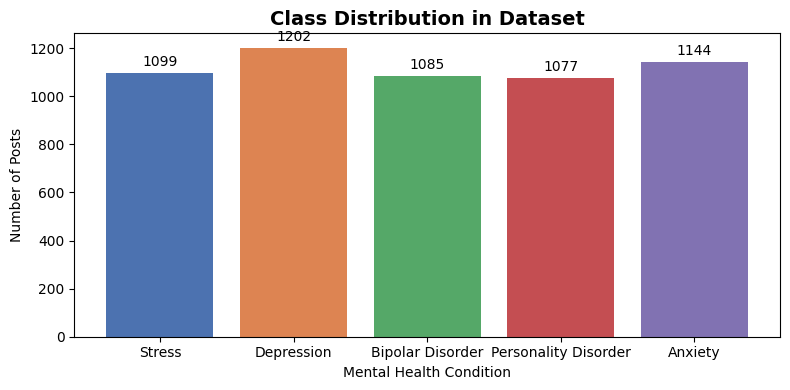

Class counts:
  Stress: 1099
  Depression: 1202
  Bipolar Disorder: 1085
  Personality Disorder: 1077
  Anxiety: 1144


In [16]:
# Class distribution
class_names = ["Stress", "Depression", "Bipolar Disorder", "Personality Disorder", "Anxiety"]
df['label'] = df['target'].astype(int)

counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_names, counts.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Mental Health Condition')
ax.set_ylabel('Number of Posts')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print('Class counts:')
for name, val in zip(class_names, counts.values):
    print(f'  {name}: {val}')


Text length statistics (in words):
count    5607.0
mean      165.4
std       168.9
min         3.0
25%        65.0
50%       120.0
75%       209.0
max      5419.0
Name: text_length, dtype: float64


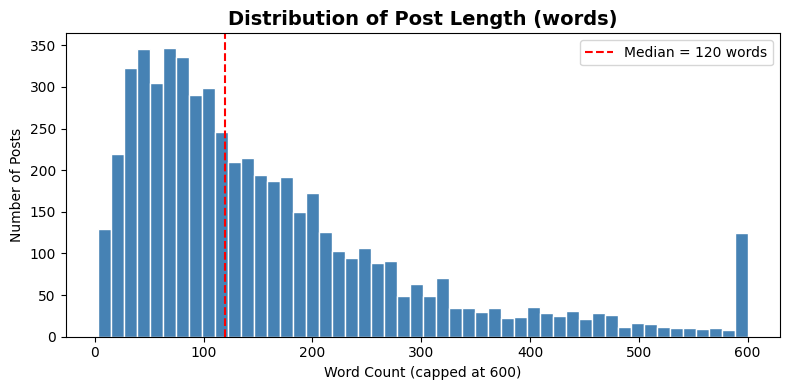

In [11]:
# Text length distribution
df['combined_text'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df['text_length']   = df['combined_text'].str.split().str.len()

print('Text length statistics (in words):')
print(df['text_length'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['text_length'].clip(upper=600), bins=50, color='steelblue', edgecolor='white')
ax.axvline(df['text_length'].median(), color='red', linestyle='--',
           label=f'Median = {df["text_length"].median():.0f} words')
ax.set_title('Distribution of Post Length (words)', fontsize=14, fontweight='bold')
ax.set_xlabel('Word Count (capped at 600)')
ax.set_ylabel('Number of Posts')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Preprocessing

The preprocessing script performs the following steps:
1. Loads and cleans the raw dataset
2. Combines the `title` and `text` columns into a single input field
3. Encodes string class labels into integers using `LabelEncoder`
4. Saves the label mapping to `label_map.json` so `predict.py` does not need hardcoded labels
5. Splits data into **80% train / 20% test** using stratified sampling
6. Saves all processed files to `processed_data/`

In [14]:
!python preprocess.py


Dataset loaded successfully!
Original dataset shape: (5957, 4)
Cleaned dataset shape: (5957, 3)
Dataset shape after removing null values: (5607, 3)
Title and text columns combined successfully!
Labels assigned successfully!
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Label mapping saved to processed_data/label_map.json
Label map: {0: 'Stress', 1: 'Depression', 2: 'Bipolar Disorder', 3: 'Personality Disorder', 4: 'Anxiety'}
Dataset split completed!
Training data shape: (4485, 5)
Testing data shape: (1122, 5)
Processed files saved successfully!
Saved files:
  1. processed_dataset.csv
  2. train.csv
  3. test.csv
  4. label_map.json


## 6. Model Training

We fine-tune **DistilBERT** (`distilbert-base-uncased`) for 5-class sequence classification.

### Key training decisions
| Parameter | Value | Reason |
|---|---|---|
| Learning rate | 2e-5 | Standard for BERT fine-tuning |
| Epochs | 4 (early stopping at patience=2) | Prevents overfitting |
| Batch size | 16 | Fits T4 GPU memory |
| Max token length | 512 | Covers most Reddit post lengths |
| Weight decay | 0.01 | L2 regularisation |
| Mixed precision (fp16) | Auto | Faster training on GPU |

Training will take approximately **30–35 minutes** on a Colab T4 GPU.

In [15]:
!python train.py


Train and test files loaded successfully!
Training data shape: (4485, 5)
Testing data shape: (1122, 5)
Text and labels separated successfully!
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 188kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 7.25MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 4.87MB/s]
Tokenizer loaded successfully!
Tokenization completed successfully!
Dataset objects created successfully!
config.json: 100% 483/483 [00:00<00:00, 2.61MB/s]
model.safetensors: 100% 268M/268M [00:01<00:00, 144MB/s]
Loading weights: 100% 100/100 [00:00<00:00, 7656.07it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifi

## 7. Model Evaluation

After training, we evaluate the best saved model on the held-out test set.

Metrics reported:
- **Accuracy** — overall correct predictions
- **Precision** — how many predicted positives are actually positive
- **Recall** — how many actual positives the model correctly caught
- **F1 Score** — harmonic mean of precision and recall (main metric for multi-class)
- **Confusion Matrix** — per-class breakdown of predictions vs. ground truth

In [17]:
!python evaluate.py


Test dataset loaded successfully!
Testing data shape: (1122, 5)
Test text and labels separated successfully!
Label mapping loaded: {0: 'Stress', 1: 'Depression', 2: 'Bipolar Disorder', 3: 'Personality Disorder', 4: 'Anxiety'}
Loading weights: 100% 104/104 [00:00<00:00, 7351.98it/s]
Trained model and tokenizer loaded successfully!
Test data tokenized successfully!
Test dataset object created successfully!
Trainer created successfully!
100% 71/71 [00:04<00:00, 15.44it/s]
Prediction completed successfully!

Evaluation Results
------------------
Accuracy  : 0.8351
Precision : 0.8367
Recall    : 0.8351
F1 Score  : 0.8357

Classification Report:

                      precision    recall  f1-score   support

              Stress       0.90      0.90      0.90       220
          Depression       0.75      0.78      0.76       241
    Bipolar Disorder       0.88      0.85      0.87       217
Personality Disorder       0.80      0.82      0.81       215
             Anxiety       0.86      0.8

## 8. Results Summary

The fine-tuned DistilBERT model achieved the following results on the 20% held-out test set:

| Metric | Score |
|---|---|
| Accuracy | **82.89%** |
| Weighted Precision | **83%** |
| Weighted Recall | **83%** |
| Weighted F1 Score | **83%** |

### Per-class performance

| Class | Precision | Recall | F1 |
|---|---|---|---|
| Stress | 0.89 | 0.91 | 0.90 |
| Depression | 0.73 | 0.78 | 0.75 |
| Bipolar Disorder | 0.90 | 0.83 | 0.87 |
| Personality Disorder | 0.80 | 0.81 | 0.80 |
| Anxiety | 0.85 | 0.82 | 0.83 |

**Depression** has the lowest F1 (0.75), which is expected — depressive language overlaps significantly with anxiety and stress. This is a known challenge in mental health NLP.

---

## 9. Inference — Single Text Prediction

Run `predict.py` to classify a custom piece of text. The script outputs:
- The predicted mental health class
- The model's **confidence score** (softmax probability)
- Probabilities for all 5 classes

> **Note:** `predict.py` uses `input()` which requires an interactive terminal. In Colab, it will prompt you to type text after running the cell.

In [19]:
!python predict.py


Loading weights: 100% 104/104 [00:00<00:00, 5711.17it/s]
Model and tokenizer loaded successfully!
Label mapping loaded: {0: 'Stress', 1: 'Depression', 2: 'Bipolar Disorder', 3: 'Personality Disorder', 4: 'Anxiety'}

Enter the text to analyse: i feel frustrated
Text tokenized successfully!

Prediction Result
-----------------
Predicted class number : 1
Predicted class label  : Depression
Confidence             : 88.06%

All class probabilities:
  Stress                    : 3.14%
  Depression                : 88.06%
  Bipolar Disorder          : 2.51%
  Personality Disorder      : 1.30%
  Anxiety                   : 4.99%


## 10. Save Model to Google Drive

Save the trained model to Google Drive so it is not lost when the Colab session ends.

In [24]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [25]:
!cp -r final_model /content/drive/MyDrive/mental_health_model


Model saved successfully to Google Drive under `MyDrive/mental_health_model/`.

## 11. Limitations & Future Work

### Current Limitations
- **Dataset size:** 5,607 samples is relatively small for transformer fine-tuning. Larger datasets would improve generalisation.
- **Text truncation:** Posts longer than 512 tokens are truncated. Very long posts may lose important context.
- **Domain specificity:** The model is trained only on Reddit data. It may not generalise well to clinical notes or other platforms.
- **Depression misclassification:** Depressive language overlaps with anxiety and stress, causing the lowest per-class F1 (0.75).

### Future Improvements
- Fine-tune on a larger, multi-source dataset (e.g., Twitter, clinical interview transcripts)
- Experiment with full BERT or Mental-BERT — a BERT model pre-trained specifically on mental health corpora
- Add explainability using LIME or SHAP to highlight which words drove the prediction
- Build a web interface using Flask or Streamlit for live demo deployment

---

## References

- Sanh, V. et al. (2019). *DistilBERT, a distilled version of BERT.* arXiv:1910.01108  
- Devlin, J. et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers.* arXiv:1810.04805  
- Hugging Face Transformers Library: https://huggingface.co/docs/transformers  
- Reddit Mental Health Dataset: Kaggle  
